# 01 — Istraživanje skupa podataka (Data Exploration)

Cilj ovog notebook-a je da:
- preuzmemo i pripremimo Dogs vs Cats dataset sa Kaggle-a,
- provjerimo strukturu, integritet i osnovna svojstva podataka (balans klasa, dimenzije slika, boja),
- napravimo **train/validation/test split** koji će se koristiti u svim narednim notebook-ovima (baseline model, transfer learning, fine-tuning), da bi svi modeli bili fer upoređeni na istim podacima.

Radi se u Google Colab-u (GPU), a podaci se čuvaju na Google Drive-u između sesija.


## 1. Preuzimanje i postavljanje

U ovoj sekciji: instaliramo/ažuriramo Kaggle alat, učitavamo API token bezbjedno preko Colab Secrets-a (bez da ikad bude vidljiv u samom kodu), montiramo Google Drive za trajno skladištenje, i preuzimamo dataset.


In [ ]:
# instaliramo/ažuriramo Kaggle CLI alat (najnovija verzija, radi sa novijim tipom tokena)
!pip install -U kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 262.5/262.5 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [ ]:
# učitavamo Kaggle API token iz Colab Secrets panela (bezbjedno, bez ispisivanja u kodu)
from google.colab import userdata
import os

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [ ]:
# montiramo Google Drive da bi preuzeti podaci ostali sačuvani između Colab sesija
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

# folder na Drive-u gdje čuvamo sve podatke projekta
os.makedirs('/content/drive/MyDrive/MU-projekat/data', exist_ok=True)
os.chdir('/content/drive/MyDrive/MU-projekat/data')

# preuzimamo dataset sa Kaggle-a (Dataset mirror, ne originalni competition -
# originalni "dogs-vs-cats" competition ima pokvaren "join" tok jer je davno završen)
!kaggle datasets download -d biaiscience/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/biaiscience/dogs-vs-cats
License(s): DbCL-1.0
100% 817M/817M [00:11<00:00, 76.1MB/s]



## 2. Raspakivanje i provera strukture

Raspakujemo preuzeti zip fajl i istražujemo kako su podaci organizovani prije nego što nastavimo — bitno je znati tačnu strukturu foldera prije pisanja koda koji je koristi.

**Napomena**: dataset sadrži dva dijela — `train/train/` (25.000 OZNAČENIH slika, imena tipa `cat.N.jpg`/`dog.N.jpg`) i `test/test/` (12.500 NEoznačenih slika, imena samo `N.jpg`). Ovaj drugi je originalni Kaggle takmičarski test set čije prave labele nikad nisu javno objavljene, pa se **ne može koristiti za evaluaciju** — naš vlastiti train/val/test split pravimo isključivo iz `train/train/`.


In [ ]:
# provera da je zip fajl uspešno preuzet i kolika mu je veličina
!ls -lh

total 817M
-rw------- 1 root root 817M Sep 25  2019 dogs-vs-cats.zip


In [ ]:
# raspakujemo zip u poseban folder
# -q (quiet) sprečava ispisivanje imena svih 25000+ fajlova pojedinačno
!unzip -q dogs-vs-cats.zip -d dogs-vs-cats

In [ ]:
# pregled šta je raspakovano na najvišem nivou
!ls -lh dogs-vs-cats

total 8.0K
drwx------ 3 root root 4.0K Aug 16 08:53 test
drwx------ 3 root root 4.0K Aug 16 08:55 train


In [ ]:
# proveravamo da li su train/test folderi ugnježdeni (sadrže podfolder istog imena)
!ls -la dogs-vs-cats/train
!echo "---"
!ls -la dogs-vs-cats/test

total 4
drwx------ 2 root root 4096 Aug 16 09:03 train
---
total 4
drwx------ 2 root root 4096 Aug 16 08:55 test


In [ ]:
# prikaz par imena fajlova (da vidimo konvenciju imenovanja) i tačan broj fajlova u svakom skupu
!ls dogs-vs-cats/train/train | head -5
!ls dogs-vs-cats/train/train | wc -l
!echo "---"
!ls dogs-vs-cats/test/test | head -5
!ls dogs-vs-cats/test/test | wc -l

cat.0.jpg
cat.10000.jpg
cat.10001.jpg
cat.10002.jpg
cat.10003.jpg
25000
---
10000.jpg
10001.jpg
10002.jpg
10003.jpg
10004.jpg
12500


## 3. Balans klasa

Provjeravamo koliko od 25.000 slika u `train/train/` pripada svakoj klasi — balansiran skup (približno jednak broj po klasi) je važan jer sprječava da model "prevari" tako što uvijek predviđa dominantniju klasu.


In [ ]:
# brojimo koliko fajlova počinje sa "cat" odnosno "dog" da provjerimo balans klasa
!ls dogs-vs-cats/train/train | grep -c '^cat'
!ls dogs-vs-cats/train/train | grep -c '^dog'

12500
12500


## 4. Integritet i svojstva slika

Prolazimo kroz sve slike i provjeravamo:
- da li su sve čitljive (ima li oštećenih/pokidanih fajlova),
- kolike su im dimenzije (očekujemo velike razlike, pošto su slike prikupljene sa interneta, ne fotografisane pod istim uslovima),
- da li su sve u boji (RGB) ili ima i crno-bijelih (grayscale) slika — ovo je bitno znati unaprijed jer modeli obično očekuju dosljedan broj kanala (3 za RGB) na ulazu.


In [ ]:
from PIL import Image
import os

train_dir = 'dogs-vs-cats/train/train'
files = os.listdir(train_dir)

corrupted = []
sizes = []
modes = []

for fname in files:
    path = os.path.join(train_dir, fname)
    try:
        # verify() provjerava da je fajl strukturno ispravan (nije pokidan/oštećen),
        # bez potpunog dekodiranja slike
        with Image.open(path) as img:
            img.verify()
        # slika se mora ponovo otvoriti nakon verify() jer taj objekat
        # više nije pouzdan za dalje čitanje (ograničenje PIL biblioteke)
        with Image.open(path) as img:
            sizes.append(img.size)   # (širina, visina) u pikselima
            modes.append(img.mode)   # npr. 'RGB' (boja) ili 'L' (crno-bijelo/grayscale)
    except Exception as e:
        # ako otvaranje/verifikacija ne uspije, fajl se smatra oštećenim
        corrupted.append((fname, str(e)))

print(f"Broj oštećenih fajlova: {len(corrupted)}")
print(corrupted[:10])  # prikazujemo samo prvih 10, za slučaj da ih ima puno

Broj oštećenih fajlova: 0
[]


In [ ]:
import numpy as np
from collections import Counter

# izdvajamo širine i visine iz liste (sizes) koju smo sakupili u prethodnoj ćeliji
widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f"Širina: min={min(widths)}, max={max(widths)}, prosjek={np.mean(widths):.0f}")
print(f"Visina: min={min(heights)}, max={max(heights)}, prosjek={np.mean(heights):.0f}")

# Counter prebroji koliko puta se svaki "mode" (RGB, L, ...) pojavljuje
print(Counter(modes))

Širina: min=42, max=1050, prosjek=404
Visina: min=32, max=768, prosjek=360
Counter({'RGB': 25000})


## 5. Vizuelni primeri

Prikazujemo nekoliko nasumično odabranih slika da vizuelno potvrdimo ono što brojevi pokazuju — različite pozadine, uglovi, ponekad i deo čoveka u kadru.


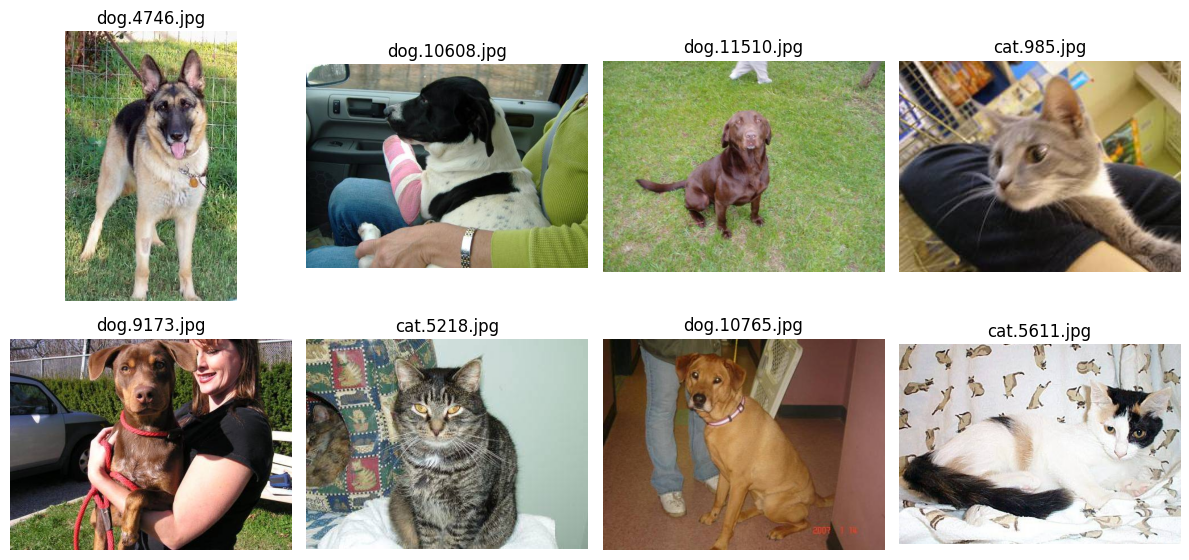

In [ ]:
import matplotlib.pyplot as plt
import random

# nasumično biramo 8 slika (bez ponavljanja) da vizuelno pogledamo primere
sample_files = random.sample(files, 8)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, fname in zip(axes.flat, sample_files):
    img = Image.open(os.path.join(train_dir, fname))
    ax.imshow(img)
    ax.set_title(fname)
    ax.axis('off')  # sklanjamo ose koordinata, nisu potrebne za prikaz slike
plt.tight_layout()
plt.show()

## 6. Train / Validation / Test split

Ovo je najvažniji deo ovog notebook-a — delimo 25.000 označenih slika na tri skupa:

- **Train (80%, 20.000 slika)** — na ovome se model direktno uči
- **Validation (16%, 4.000 slika)** — koristi se tokom treninga da pratimo da li model overfituje, i za biranje hiperparametara
- **Test (4%, 1.000 slika)** — dira se SAMO JEDNOM, na kraju, za finalnu, nepristrasnu procjenu najboljeg modela

Split je **stratifikovan** (svaka grupa zadržava 50/50 omjer cat/dog) i koristi **fiksni random seed (42)** da bude reproducibilan. Rezultat čuvamo kao CSV (`split.csv`) koji ide u git repo — svi naredni notebook-i (i Almini i Mini) učitavaju TAJ ISTI fajl umjesto da split prave iznova, čime osiguravamo da se svi modeli fer upoređuju na identičnim podacima.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# gradimo tabelu (filename, label) - labela se čita direktno iz imena fajla
records = []
for fname in files:
    label = 'cat' if fname.startswith('cat') else 'dog'
    records.append({'filename': fname, 'label': label})

df = pd.DataFrame(records)

# 1. korak: izdvajamo test set (4% = 1000 slika) iz CIJELOG skupa
# stratify=... garantuje da i test i "ostatak" zadrže isti omer cat/dog (50/50)
train_val_df, test_df = train_test_split(
    df, test_size=0.04, stratify=df['label'], random_state=42
)

# 2. korak: od preostalih 24000 slika izdvajamo validation set
# želimo val=4000 OD ORIGINALNIH 25000, a dijelimo skup od 24000,
# zato je omer 4000/24000 (~16.7%), NE 0.16 - inače bismo dobili pogrešan broj slika
train_df, val_df = train_test_split(
    train_val_df, test_size=4000/24000, stratify=train_val_df['label'], random_state=42
)

# označavamo kojoj grupi svaki red pripada i spajamo sve u jednu tabelu
train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()
train_df['split'] = 'train'
val_df['split'] = 'val'
test_df['split'] = 'test'

split_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

# provera: očekujemo train=20000, val=4000, test=1000, i 50/50 cat/dog u svakoj grupi
print(split_df['split'].value_counts())
print(split_df.groupby(['split', 'label']).size())

# čuvamo split kao CSV - ovaj fajl (ne slike) ide u git repo,
split_df.to_csv('/content/drive/MyDrive/MU-projekat/data/split.csv', index=False)

split
train    20000
val       4000
test      1000
Name: count, dtype: int64
split  label
test   cat        500
       dog        500
train  cat      10000
       dog      10000
val    cat       2000
       dog       2000
dtype: int64


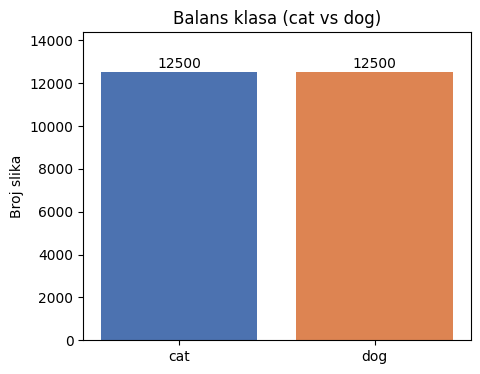

In [ ]:
import matplotlib.pyplot as plt

# brojimo ukupan broj slika po labeli (cat/dog) u cijelom split_df
counts = split_df['label'].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])
plt.title('Balans klasa (cat vs dog)')
plt.ylabel('Broj slika')
for i, v in enumerate(counts.values):
    plt.text(i, v + 200, str(v), ha='center')  # ispisujemo tačan broj iznad stubića
plt.ylim(0, max(counts.values) * 1.15)  # ostavljamo prostor iznad stubića za tekst
plt.show()